In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot  as plt
from modules.v1.neural_network import NeuralNetworkTrainable
from modules.v1.convolution_2d import Conv2DTrainable
from modules.v1.sequential_framework import SeqFrameworkTrainable
from modules.v1.flatten import FlattenMatrix

In [ ]:
data_file_path = "./data/MNIST_CSV/mnist_train.csv"

df = pd.read_csv(data_file_path)

df.head(20)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
Y = df.iloc[0:, 0:1]
x = df.iloc[0:, 1:] / 255

In [9]:
x = x.to_numpy()
Y = Y.to_numpy()
print(x.shape, Y.shape)

(59999, 784) (59999, 1)


In [10]:
x = x.reshape(59999, 1, 28, 28)

In [11]:
nb_classes = 10
Y.shape
one_hot_targets = np.eye(nb_classes)[Y]
one_hot_targets = one_hot_targets.reshape(one_hot_targets.shape[0], -1)

In [12]:
x.shape, one_hot_targets.shape

((59999, 1, 28, 28), (59999, 10))

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


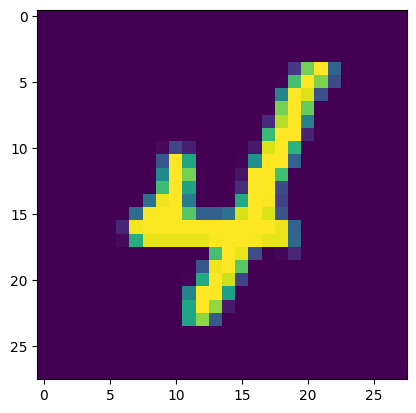

In [ ]:
random_choice = np.random.randint(0, 5999)
print(one_hot_targets[random_choice])
plt.imshow(x[random_choice][0])
plt.show()

In [14]:
conv1 = Conv2DTrainable(in_channel=1, out_channel=8, kernel_size=8, activation_func="relu")
conv2 = Conv2DTrainable(in_channel=8, out_channel=2, kernel_size=8, activation_func="relu")
conv3 = Conv2DTrainable(in_channel=2, out_channel=1, kernel_size=8, activation_func="sigmoid")
flattenlayer = FlattenMatrix()
nnlayer = NeuralNetworkTrainable(input_size=49, output_size=10)

model = SeqFrameworkTrainable()

model.add(conv1)
model.add(conv2)
model.add(conv3)
model.add(flattenlayer)
model.add(nnlayer)

epochs = 100
lr = 0.01
batch_size = 128
model.train(x=x, Y=one_hot_targets, epochs=epochs, lr=lr)

epoch 0 loss: 0.11580073819771479
epoch 1 loss: 0.11467899598577246
epoch 2 loss: 0.11397461487922099
epoch 3 loss: 0.11278371059491384
epoch 4 loss: 0.11191314920485496
epoch 5 loss: 0.11070566880499028
epoch 6 loss: 0.10997393558091635
epoch 7 loss: 0.10874335754379441
epoch 8 loss: 0.10785569789448186
epoch 9 loss: 0.10677878821875464
epoch 10 loss: 0.10551642539199814
epoch 11 loss: 0.10443196718651579
epoch 12 loss: 0.10331513091953966
epoch 13 loss: 0.10178535644419337
epoch 14 loss: 0.10087070100924253
epoch 15 loss: 0.09952882244189927
epoch 16 loss: 0.09786878446727355
epoch 17 loss: 0.09693793073752557
epoch 18 loss: 0.09559263006330516
epoch 19 loss: 0.09429753271589768
epoch 20 loss: 0.09274400439959551
epoch 21 loss: 0.09126921186205213
epoch 22 loss: 0.0897315165563003
epoch 23 loss: 0.08810330909119217
epoch 24 loss: 0.08654671554422372
epoch 25 loss: 0.08511885552088193
epoch 26 loss: 0.08381196481411261
epoch 27 loss: 0.082456229360435
epoch 28 loss: 0.0810435376919084